In [43]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [44]:
PACKAGE_USED = 0  # 0 = sklearn; 1 = sktime; 2 = aeon

In [45]:
APPROACH = "svm"

In [46]:
CHANNEL_CONFIG = "g-a"

In [47]:
TRAIN_DIR = [
    R"dataset_30hz"
]

In [48]:
TEST_DIR = [
    R"dataset_30hz"
]

# Build DataFrame

In [49]:
def build_df(dirs):
    """
    dirs: list of directory paths containing CSV files
    """
    all_csv_files = []

    for _DIR in dirs:
        file_pattern = os.path.join(_DIR, "*.csv")
        csv_files = glob.glob(file_pattern)
        print(f"{_DIR} -> {len(csv_files)} CSV files found")
        all_csv_files.extend(csv_files)

    print(f"A total of {len(all_csv_files)} CSV files were used in constructing this DataFrame.")

    if not all_csv_files:
        raise ValueError("No CSV files found in the provided directories.")

    df = pd.concat((pd.read_csv(f) for f in all_csv_files), ignore_index=True)
    return df

In [50]:
df_train = build_df(TRAIN_DIR)

dataset_30hz -> 36 CSV files found
A total of 36 CSV files were used in constructing this DataFrame.


In [51]:
df_test = build_df(TEST_DIR)

dataset_30hz -> 36 CSV files found
A total of 36 CSV files were used in constructing this DataFrame.


In [52]:
print(df_train.duplicated().sum())

0


In [53]:
print(df_test.duplicated().sum())

0


In [54]:
df_train.drop_duplicates(inplace=True)

In [55]:
df_test.drop_duplicates(inplace=True)

## Remove unneeded columns

In [56]:
match CHANNEL_CONFIG:
    case "gyro":
        df_train = df_train.filter(regex=r'^(gyro|motion)')
        df_test = df_test.filter(regex=r'^(gyro|motion)')
    case "accel":
        df_train = df_train.filter(regex=r'^(acc|motion)')
        df_test = df_test.filter(regex=r'^(acc|motion)')
    case "mag":
        df_train = df_train.filter(regex=r'^(mag|motion)')
        df_test = df_test.filter(regex=r'^(mag|motion)')
    case "ahrs":
        df_train = df_train.filter(regex=r'^(ahrs|motion)')
        df_test = df_test.filter(regex=r'^(ahrs|motion)')
    case "g-a":
        df_train = df_train.filter(regex=r'^(gyro|acc|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|motion)')
    case "g-m":
        df_train = df_train.filter(regex=r'^(gyro|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|mag|motion)')
    case "a-m":
        df_train = df_train.filter(regex=r'^(acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(acc|mag|motion)')
    case "g-a-m":
        df_train = df_train.filter(regex=r'^(gyro|acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|mag|motion)')
    case _:
        pass

In [57]:
# df_train = df_train.drop(df_train[df_train["motion_type"] == "POUR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_UP"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_DOWN"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "STIR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "ROLL"].index)


In [58]:
df_train.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_13,acc_y_13,acc_z_13,gyro_x_14,gyro_y_14,gyro_z_14,acc_x_14,acc_y_14,acc_z_14,motion_type
0,0.000000,0.000000,0.000000,0.000000,0.0,-0.000137,-0.386512,-1.276550,-6.054812,-4.534200,...,11.743051,5.33595,-11.856001,5.41305,-6.09795,2.15400,4.82805,0.44700,1.17000,HIT
1,0.000137,0.000137,0.000137,0.000137,0.0,-0.141625,-0.917812,-7.103938,-6.080250,-6.152163,...,5.254950,-4.47495,4.623000,6.25305,-2.94000,3.72000,2.98995,0.49995,1.24695,HIT
2,0.000000,0.000000,0.000000,0.000000,0.0,-0.147813,-0.526075,-2.105537,-6.973037,-4.341975,...,12.646050,2.82000,-6.874050,-5.43495,4.14900,-0.51000,2.23995,2.02200,0.63600,HIT
3,0.000000,0.000000,0.000137,0.000000,0.0,-0.000137,-0.769037,-4.475488,-7.729562,-3.684862,...,7.897950,1.42395,-14.368051,2.06505,-2.06805,-0.18705,3.04695,0.36795,0.30300,HIT
4,0.000000,0.000000,0.000000,0.000000,0.0,0.000137,0.000000,-0.855250,-4.271025,-3.149163,...,11.962951,5.20395,-7.936950,12.47595,-0.16500,-3.30600,5.61900,1.21995,-0.39195,HIT


In [59]:
df_test.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_13,acc_y_13,acc_z_13,gyro_x_14,gyro_y_14,gyro_z_14,acc_x_14,acc_y_14,acc_z_14,motion_type
0,0.000000,0.000000,0.000000,0.000000,0.0,-0.000137,-0.386512,-1.276550,-6.054812,-4.534200,...,11.743051,5.33595,-11.856001,5.41305,-6.09795,2.15400,4.82805,0.44700,1.17000,HIT
1,0.000137,0.000137,0.000137,0.000137,0.0,-0.141625,-0.917812,-7.103938,-6.080250,-6.152163,...,5.254950,-4.47495,4.623000,6.25305,-2.94000,3.72000,2.98995,0.49995,1.24695,HIT
2,0.000000,0.000000,0.000000,0.000000,0.0,-0.147813,-0.526075,-2.105537,-6.973037,-4.341975,...,12.646050,2.82000,-6.874050,-5.43495,4.14900,-0.51000,2.23995,2.02200,0.63600,HIT
3,0.000000,0.000000,0.000137,0.000000,0.0,-0.000137,-0.769037,-4.475488,-7.729562,-3.684862,...,7.897950,1.42395,-14.368051,2.06505,-2.06805,-0.18705,3.04695,0.36795,0.30300,HIT
4,0.000000,0.000000,0.000000,0.000000,0.0,0.000137,0.000000,-0.855250,-4.271025,-3.149163,...,11.962951,5.20395,-7.936950,12.47595,-0.16500,-3.30600,5.61900,1.21995,-0.39195,HIT


C:\Users\samue\AppData\Local\Temp\ipykernel_33624\1258022319.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distribusi, x='Nama Gestur', y='Jumlah Sampel', palette='viridis')


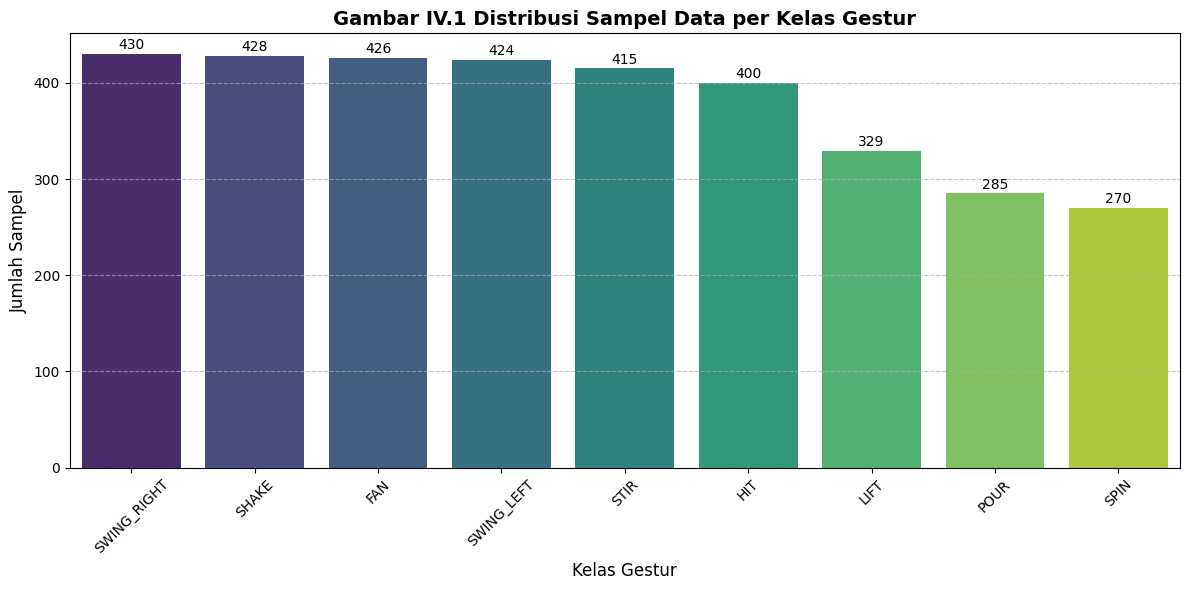

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

distribusi = df_train['motion_type'].value_counts().reset_index()
distribusi.columns = ['Nama Gestur', 'Jumlah Sampel']

plt.figure(figsize=(12, 6))
sns.barplot(data=distribusi, x='Nama Gestur', y='Jumlah Sampel', palette='viridis')
plt.title('Gambar IV.1 Distribusi Sampel Data per Kelas Gestur', fontsize=14, fontweight='bold')
plt.xlabel('Kelas Gestur', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in distribusi.iterrows():
    plt.text(index, row['Jumlah Sampel'] + 5, str(row['Jumlah Sampel']), color='black', ha="center")

plt.tight_layout()
plt.show()

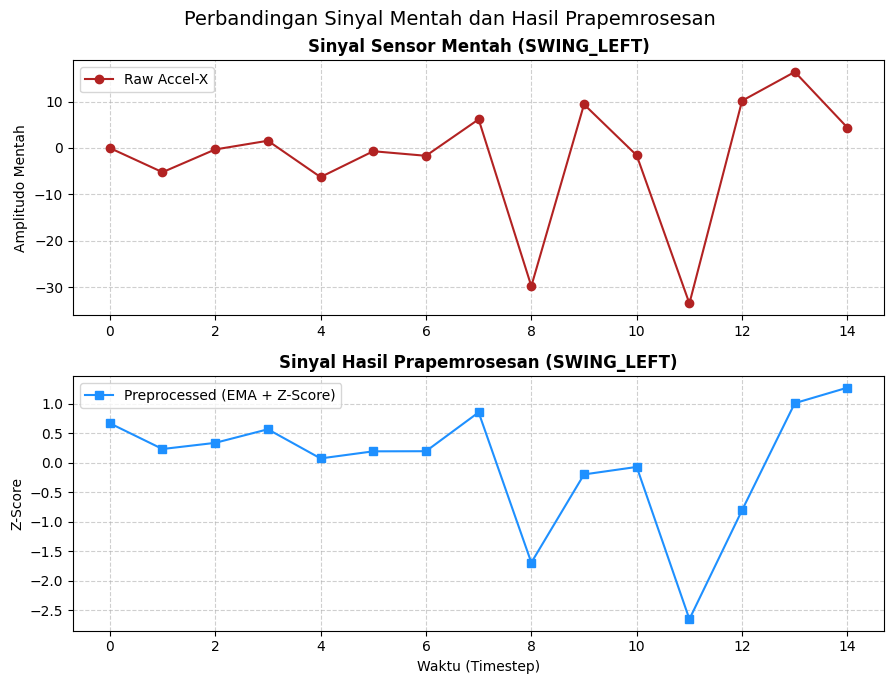

In [61]:
from scipy.stats import zscore

LABEL_NAME = 'SWING_LEFT'
sample_data = df_train[df_train['motion_type'] == LABEL_NAME].iloc[0]

timesteps = 15
acc_x_raw = [sample_data[f'acc_x_{i}'] for i in range(timesteps)]

# Preprocessing
# 1. Low-Pass Filter (Exponential Moving Average)
def ema_filter(data, alpha=0.3):
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[i-1])
    return ema

acc_x_ema = ema_filter(acc_x_raw, alpha=0.3)

# 2. Standarization
acc_x_prep = zscore(acc_x_ema)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(9, 7))

# Plot Atas: Sinyal Mentah
axes[0].plot(acc_x_raw, marker='o', color='firebrick', label='Raw Accel-X')
axes[0].set_title(f"Sinyal Sensor Mentah ({LABEL_NAME})", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Amplitudo Mentah")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot Bawah: Sinyal Preprocessed
axes[1].plot(acc_x_prep, marker='s', color='dodgerblue', label='Preprocessed (EMA + Z-Score)')
axes[1].set_title(f"Sinyal Hasil Prapemrosesan ({LABEL_NAME})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Waktu (Timestep)")
axes[1].set_ylabel("Z-Score")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.suptitle("Perbandingan Sinyal Mentah dan Hasil Prapemrosesan", y=0.97, fontsize=14)
plt.tight_layout()
plt.show()

In [62]:
# sns.countplot(df_train, x="motion_type", hue="motion_type")

In [63]:
len(df_train)

3407

In [64]:
# sns.countplot(df_test, x="motion_type", hue="motion_type")

In [65]:
len(df_test)

3407

## Get X and y

In [66]:
from sklearn.preprocessing import LabelEncoder

In [67]:
def get_X_and_y(df: pd.DataFrame, package_used: int) -> tuple[np.array, np.array]:
    if package_used == 0:  # sklearn
        X = df.drop(columns=["motion_type"]).values
        y = df["motion_type"].values
        return X.astype("float32"), y
    
    elif package_used == 1:  # sktime
        X_df = df.drop(columns=["motion_type"])
        y = df["motion_type"].values
        
        n_timesteps = 30
        channels = []
        match CHANNEL_CONFIG:
            case "accel":
                channels = ["accel_x", "accel_y", "accel_z"]
            case "gyro":
                channels = ["gyro_x", "gyro_y", "gyro_z"]
            case "mag":
                channels = ["mag_x", "mag_y", "mag_z"]
            case "ahrs":
                channels = ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
            case "g-a":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"]
            case "g-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"]
            case "a-m":
                channels = ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case "g-a-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case _:
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z", "ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
        n_channels = len(channels)

        X = np.zeros((len(df), n_channels, n_timesteps))

        for t in range(n_timesteps):
            for c, channel in enumerate(channels):
                col_name = f"{channel}_{t}"
        
                X[:, c, t] = X_df[col_name].values
                
        return X.astype("float32"), y

    else:  # aeon
        y = df["motion_type"].values

        n_timesteps = 30

        channels = {
            "accel": ["accel_x", "accel_y", "accel_z"],
            "gyro": ["gyro_x", "gyro_y", "gyro_z"],
            "mag": ["mag_x", "mag_y", "mag_z"],
            "ahrs": ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"],
            "g-a": ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"],
            "g-m": ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"],
            "a-m": ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"],
            "g-a-m": ["gyro_x", "gyro_y", "gyro_z",
                    "accel_x", "accel_y", "accel_z",
                    "mag_x", "mag_y", "mag_z"],
        }.get(CHANNEL_CONFIG, [
            "gyro_x","gyro_y","gyro_z",
            "accel_x","accel_y","accel_z",
            "mag_x","mag_y","mag_z",
            "ahrs_x","ahrs_y","ahrs_z","ahrs_w"
        ])

        n_channels = len(channels)
        X = np.zeros((len(df), n_channels, n_timesteps), dtype="float32")

        for t in range(n_timesteps):
            for c, ch in enumerate(channels):
                X[:, c, t] = df[f"{ch}_{t}"].values

        return X.astype("float32"), y

In [68]:
X_train, y_train = get_X_and_y(df_train, PACKAGE_USED)
X_test, y_test = get_X_and_y(df_test, PACKAGE_USED)

In [69]:
X_train.shape

(3407, 90)

In [70]:
y_train

array(['HIT', 'HIT', 'HIT', ..., 'LIFT', 'LIFT', 'LIFT'],
      shape=(3407,), dtype=object)

In [71]:
mapping = {'HIT': 0, 'SHAKE': 1, 'SWING_LEFT': 2, 'SWING_RIGHT': 3, 'FAN': 4, 'IDLE': 5, 'STIR': 6, 'LIFT': 7, 'SPIN': 8, 'POUR': 9}
y_train = np.vectorize(mapping.get)(y_train)
y_test = np.vectorize(mapping.get)(y_test)

In [72]:
unk_train = set(y_train) - set(mapping.keys())
print(f"Unknown labels in y_train: {unk_train}")

Unknown labels in y_train: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


In [73]:
# from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
# from sktime.classification.deep_learning import InceptionTimeClassifier
from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from xgboost import XGBClassifier
from aeon.classification.deep_learning import LITETimeClassifier

In [74]:
if PACKAGE_USED == 0:
    if APPROACH.lower() == "svm":
        clf_minirocket = SVC()
    elif APPROACH.lower() == "rf":
        clf_minirocket = RandomForestClassifier()
    elif APPROACH.lower() == "softmax":
        clf_minirocket = LogisticRegression(solver = "saga", max_iter=1000)

In [75]:
if PACKAGE_USED == 1:
    if APPROACH.lower() == "knn":
        clf_minirocket = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
    elif APPROACH.lower() == "minirocket":
        clf_minirocket = make_pipeline(
            MiniRocketMultivariate(random_state=42),
            RidgeClassifier(alpha=1.0)
        )

In [76]:
if PACKAGE_USED == 2:
    if APPROACH.lower() == "litemvtime":
        clf_minirocket = LITETimeClassifier(use_litemv=True)

In [77]:
clf_minirocket.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [78]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [79]:
y_pred_train = clf_minirocket.predict(X_train)

In [80]:
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, average="weighted"))
print(recall_score(y_train, y_pred_train, average="weighted"))
print(f1_score(y_train, y_pred_train, average="weighted"))

0.9985324332257117
0.9985358432496833
0.9985324332257117
0.9985319110214096


In [81]:
y_pred_test = clf_minirocket.predict(X_test)

In [82]:
print(accuracy_score(y_test, y_pred_test))
print(precision_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(recall_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(f1_score(y_test, y_pred_test, average="weighted", zero_division=0))

0.9985324332257117
0.9985358432496833
0.9985324332257117
0.9985319110214096


In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_test)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_names = le.classes_.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,              # use cm for raw counts
    annot=True,                 # write numbers inside cells
    fmt=".2f",                  # 2 decimal places
    cmap="Blues",               # color style
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(f"cmat_{APPROACH}.png")
plt.show()

NameError: name 'cm' is not defined

In [84]:
from sklearn.metrics import classification_report

In [85]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       428
           2       1.00      1.00      1.00       424
           3       1.00      1.00      1.00       430
           4       1.00      1.00      1.00       426
           6       1.00      1.00      1.00       415
           7       1.00      1.00      1.00       329
           8       1.00      1.00      1.00       270
           9       1.00      0.99      1.00       285

    accuracy                           1.00      3407
   macro avg       1.00      1.00      1.00      3407
weighted avg       1.00      1.00      1.00      3407



In [86]:
from time import perf_counter

In [87]:
t0 = perf_counter()
a = clf_minirocket.predict(X_train[0:1])
t1 = perf_counter()

In [88]:
print(f"{t1 - t0} seconds taken to perform a single inference!")

0.0008193000103347003 seconds taken to perform a single inference!


In [91]:
from skl2onnx import to_onnx

if PACKAGE_USED == 0:
    onx = to_onnx(clf_minirocket, X_train[:1])
    with open(f"clf_{APPROACH}_ori.onnx", "wb") as f:
        f.write(onx.SerializeToString())

In [90]:
from joblib import dump

dump(clf_minirocket, f"clf_{APPROACH}_ori.joblib")

['clf_svm_ori.joblib']

In [ ]:
# clf_minirocket.predict(X_train[0:1])

In [ ]:
# print(repr(X_train[0:1]))

In [ ]:
# print(repr(y_train[0]))